## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">DATA SCIENCE ... PROJECT</p>

<a id="toc"></a>

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Content</p>

* [INTRODUCTION](#0)
* [IMPORTING MODULES, LOADING DATA & DATA REVIEW](#1)
* [PREPROCESSING](#2)
* [EXPLORATORY DATA ANALYSIS (EDA)](#3)    
* [SCALING, CATEGORICAL VARIABLES, SPLITTING](#4)
* [MODELS](#5)
* [CONCLUSION](#6)

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Introduction</p>

<a id="0"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true"
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

## 1.1 Information About the Project
This project focuses on building an end-to-end machine learning workflow to predict customer churn for a subscription based streaming service. Customer churn is when a user cancels their subscription and is a critical metric for subscription platforms, as retaining an existing customer is significantly more cost effective than acquiring a new one. By leveraging predictive analytics, the business can proactively identify high risk users and implement targeted retention strategies.

**Objective:**  
The primary purpose of this project is to build a robust **binary classification** model that predicts whether a user will churn (`1`) or not (`0`). The ultimate goal is to optimize predictive performance (focusing on the ROC-AUC metric to catch potential churners) and deliver a production ready model deployment pipeline.

**Scope:**  
The scope covers extensive data cleaning, handling extreme class imbalances, exploratory data analysis (EDA), feature transformations, and rigorous model tuning using various algorithms (such as Logistic Regression, LightGBM, and CatBoost). It concludes with exporting the final predictive pipeline for automated deployment. It will not cover multi-class classification or forecasting future revenue metrics.

## 1.2 Description of the Dataset
Introduce the dataset selected for the project:

- **Source:** Kaggle (Predictive Analytics for Customer Churn Dataset by Safrin).
- **Size:** The dataset contains **243,787 records** (rows) and **21 columns** (features including the unique ID and target variable).
- **Type:** Tabular (structured data containing a mixture of numerical and categorical characteristics).

## 1.3 Description of the Columns
The features represent demographic information, subscription details, and specific viewing behavior metrics:

- **Target Variable:** 
  - `Churn`: Binary indicator of whether the customer canceled their subscription (`1` = Churned, `0` = Retained).
- **Feature Variables:**
  - `CustomerID`: A unique alphanumeric string identifying each individual customer (text/string).
  - `AccountAge`: The number of months the customer has been active with the streaming service (integer).
  - `MonthlyCharges`: The monthly amount billed to the customer in USD (float).
  - `TotalCharges`: The cumulative amount billed to the customer over their account lifespan in USD (float).
  - `SubscriptionType`: The tier of the user's subscription (`Basic`, `Standard`, `Premium`) (categorical).
  - `PaymentMethod`: The method used to pay bills (`Mailed check`, `Credit card`, `Electronic check`, `Bank transfer`) (categorical).
  - `PaperlessBilling`: Whether the customer has opted for digital paperless billing (`Yes`, `No`) (categorical).
  - `ContentType`: The primary type of content the customer consumes (`Movies`, `TV Shows`, `Both`) (categorical).
  - `MultiDeviceAccess`: Whether the user accesses the platform from multiple devices (`Yes`, `No`) (categorical).
  - `DeviceRegistered`: The type of device most frequently used to stream content (`Mobile`, `Tablet`, `Computer`, `TV`) (categorical).
  - `ViewingHoursPerWeek`: The average number of hours the customer spends watching content each week (float).
  - `AverageViewingDuration`: The average length of a single viewing session in minutes (float).
  - `ContentDownloadsPerMonth`: The number of items downloaded for offline viewing per month (integer).
  - `GenrePreference`: The customer's most preferred content genre (`Sci-Fi`, `Action`, `Fantasy`, `Drama`, `Comedy`) (categorical).
  - `UserRating`: The average satisfaction rating given by the user, ranging from 1 to 5 (float).
  - `SupportTicketsPerMonth`: The number of customer support interactions initiated by the user monthly (integer).
  - `Gender`: The gender of the customer (`Male`, `Female`) (categorical).
  - `WatchlistSize`: The number of items saved in the user's personal watchlist (integer).
  - `ParentalControl`: Whether parental controls are activated on the profile (`Yes`, `No`) (categorical).
  - `SubtitlesEnabled`: Whether subtitles are toggled on by default (`Yes`, `No`) (categorical). 


---



## <p style="background-color:#9d4f8c; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Importing Modules, Load Data & Data Review</p>

<a id="1"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

In [2]:
import pandas as pd
import numpy as np
import random
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, clear_output
import pickle

from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import randint, uniform, loguniform

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC

In [3]:
warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
df_org = pd.read_csv("data/train.csv")
df = df_org.copy()
df.head(3).T

,0,1,2
AccountAge,20,57,73
MonthlyCharges,11.055215,5.175208,12.106657
TotalCharges,221.104302,294.986882,883.785952
SubscriptionType,Premium,Basic,Basic
PaymentMethod,Mailed check,Credit card,Mailed check
PaperlessBilling,No,Yes,Yes
ContentType,Both,Movies,Movies
MultiDeviceAccess,No,No,No
DeviceRegistered,Mobile,Tablet,Computer
ViewingHoursPerWeek,36.758104,32.450568,7.39516


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243787 entries, 0 to 243786
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   AccountAge                243787 non-null  int64  
 1   MonthlyCharges            243787 non-null  float64
 2   TotalCharges              243787 non-null  float64
 3   SubscriptionType          243787 non-null  str    
 4   PaymentMethod             243787 non-null  str    
 5   PaperlessBilling          243787 non-null  str    
 6   ContentType               243787 non-null  str    
 7   MultiDeviceAccess         243787 non-null  str    
 8   DeviceRegistered          243787 non-null  str    
 9   ViewingHoursPerWeek       243787 non-null  float64
 10  AverageViewingDuration    243787 non-null  float64
 11  ContentDownloadsPerMonth  243787 non-null  int64  
 12  GenrePreference           243787 non-null  str    
 13  UserRating                243787 non-null  float64
 14 

In [5]:
df.nunique()

AccountAge                     119
MonthlyCharges              243787
TotalCharges                243787
SubscriptionType                 3
PaymentMethod                    4
PaperlessBilling                 2
ContentType                      3
MultiDeviceAccess                2
DeviceRegistered                 4
ViewingHoursPerWeek         243787
AverageViewingDuration      243787
ContentDownloadsPerMonth        50
GenrePreference                  5
UserRating                  243787
SupportTicketsPerMonth          10
Gender                           2
WatchlistSize                   25
ParentalControl                  2
SubtitlesEnabled                 2
CustomerID                  243787
Churn                            2
dtype: int64

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AccountAge,243787.0,60.083758,34.285143,1.000000,30.000000,60.000000,90.000000,119.000000
MonthlyCharges,243787.0,12.490695,4.327615,4.990062,8.738543,12.495555,16.238160,19.989957
TotalCharges,243787.0,750.741017,523.073273,4.991154,329.147027,649.878487,1089.317362,2378.723844
ViewingHoursPerWeek,243787.0,20.502179,11.243753,1.000065,10.763953,20.523116,30.219396,39.999723
AverageViewingDuration,243787.0,92.264061,50.505243,5.000547,48.382395,92.249992,135.908048,179.999275
ContentDownloadsPerMonth,243787.0,24.503513,14.421174,0.000000,12.000000,24.000000,37.000000,49.000000
UserRating,243787.0,3.002713,1.155259,1.000007,2.000853,3.002261,4.002157,4.999989
SupportTicketsPerMonth,243787.0,4.504186,2.872548,0.000000,2.000000,4.000000,7.000000,9.000000
WatchlistSize,243787.0,12.018508,7.193034,0.000000,6.000000,12.000000,18.000000,24.000000
Churn,243787.0,0.181232,0.385211,0.000000,0.000000,0.000000,0.000000,1.000000


No incorrect entries such as negative values for numeric columns.

In [7]:
df.isnull().sum()

AccountAge                  0
MonthlyCharges              0
TotalCharges                0
SubscriptionType            0
PaymentMethod               0
PaperlessBilling            0
ContentType                 0
MultiDeviceAccess           0
DeviceRegistered            0
ViewingHoursPerWeek         0
AverageViewingDuration      0
ContentDownloadsPerMonth    0
GenrePreference             0
UserRating                  0
SupportTicketsPerMonth      0
Gender                      0
WatchlistSize               0
ParentalControl             0
SubtitlesEnabled            0
CustomerID                  0
Churn                       0
dtype: int64

In [8]:
df['Churn'].value_counts()

Churn
0    199605
1     44182
Name: count, dtype: int64

The target variable Churn is highly imbalanced where not churned (0) heavily outweights churned (1) users.

### Standardize Columns

In [9]:
df.columns

Index(['AccountAge', 'MonthlyCharges', 'TotalCharges', 'SubscriptionType',
       'PaymentMethod', 'PaperlessBilling', 'ContentType', 'MultiDeviceAccess',
       'DeviceRegistered', 'ViewingHoursPerWeek', 'AverageViewingDuration',
       'ContentDownloadsPerMonth', 'GenrePreference', 'UserRating',
       'SupportTicketsPerMonth', 'Gender', 'WatchlistSize', 'ParentalControl',
       'SubtitlesEnabled', 'CustomerID', 'Churn'],
      dtype='str')

In [10]:
df.columns = df.columns.str.replace(r'(?<!^)(?=[A-Z])', '_', regex=True).str.lower()

df.columns

Index(['account_age', 'monthly_charges', 'total_charges', 'subscription_type',
       'payment_method', 'paperless_billing', 'content_type',
       'multi_device_access', 'device_registered', 'viewing_hours_per_week',
       'average_viewing_duration', 'content_downloads_per_month',
       'genre_preference', 'user_rating', 'support_tickets_per_month',
       'gender', 'watchlist_size', 'parental_control', 'subtitles_enabled',
       'customer_i_d', 'churn'],
      dtype='str')

In [11]:
df = df.rename(columns={'account_age': 'account_age_months'})

df.columns

Index(['account_age_months', 'monthly_charges', 'total_charges',
       'subscription_type', 'payment_method', 'paperless_billing',
       'content_type', 'multi_device_access', 'device_registered',
       'viewing_hours_per_week', 'average_viewing_duration',
       'content_downloads_per_month', 'genre_preference', 'user_rating',
       'support_tickets_per_month', 'gender', 'watchlist_size',
       'parental_control', 'subtitles_enabled', 'customer_i_d', 'churn'],
      dtype='str')

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Preprocessing</p>

<a id="2"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

## 2.1 Data Cleaning
Cleaning the dataset is critical before any analysis. Here, we check for duplicates, remove CustomerID, and make sure there are no incorrect unique values for categorical features.


In [12]:
df.duplicated().sum()

np.int64(0)

### Customer ID

In [13]:
df['customer_i_d'].value_counts(dropna=False)

customer_i_d
CB6SXPNVZA    1
S7R2G87O09    1
EASDC20BDT    1
NPF69NT69N    1
4LGYPK7VOL    1
             ..
FBZ38J108Z    1
W4AO1Y6NAI    1
0H3SWWI7IU    1
63SJ44RT4A    1
A6IN701VRY    1
Name: count, Length: 243787, dtype: int64

In [14]:
df = df.drop(columns="customer_i_d")

### Check categorical column values

In [15]:
cat_df = df.select_dtypes(include="str")

num_df = df.select_dtypes(include=['int64', 'float64'])

In [16]:
for col in cat_df.columns:
    print(f"'{col}': {cat_df[col].unique().tolist()}")

'subscription_type': ['Premium', 'Basic', 'Standard']
'payment_method': ['Mailed check', 'Credit card', 'Electronic check', 'Bank transfer']
'paperless_billing': ['No', 'Yes']
'content_type': ['Both', 'Movies', 'TV Shows']
'multi_device_access': ['No', 'Yes']
'device_registered': ['Mobile', 'Tablet', 'Computer', 'TV']
'genre_preference': ['Sci-Fi', 'Action', 'Fantasy', 'Drama', 'Comedy']
'gender': ['Male', 'Female']
'parental_control': ['No', 'Yes']
'subtitles_enabled': ['No', 'Yes']


No incorrect entries for categorical columns.

## 2.2 Missing Value Analysis
This data contains no missing values evident from the initial data review.

## 2.3 Outlier Analysis
Outlier analysis should be handled from a domain perspective because the context of the data can significantly influence whether an outlier is a valid observation or an error.

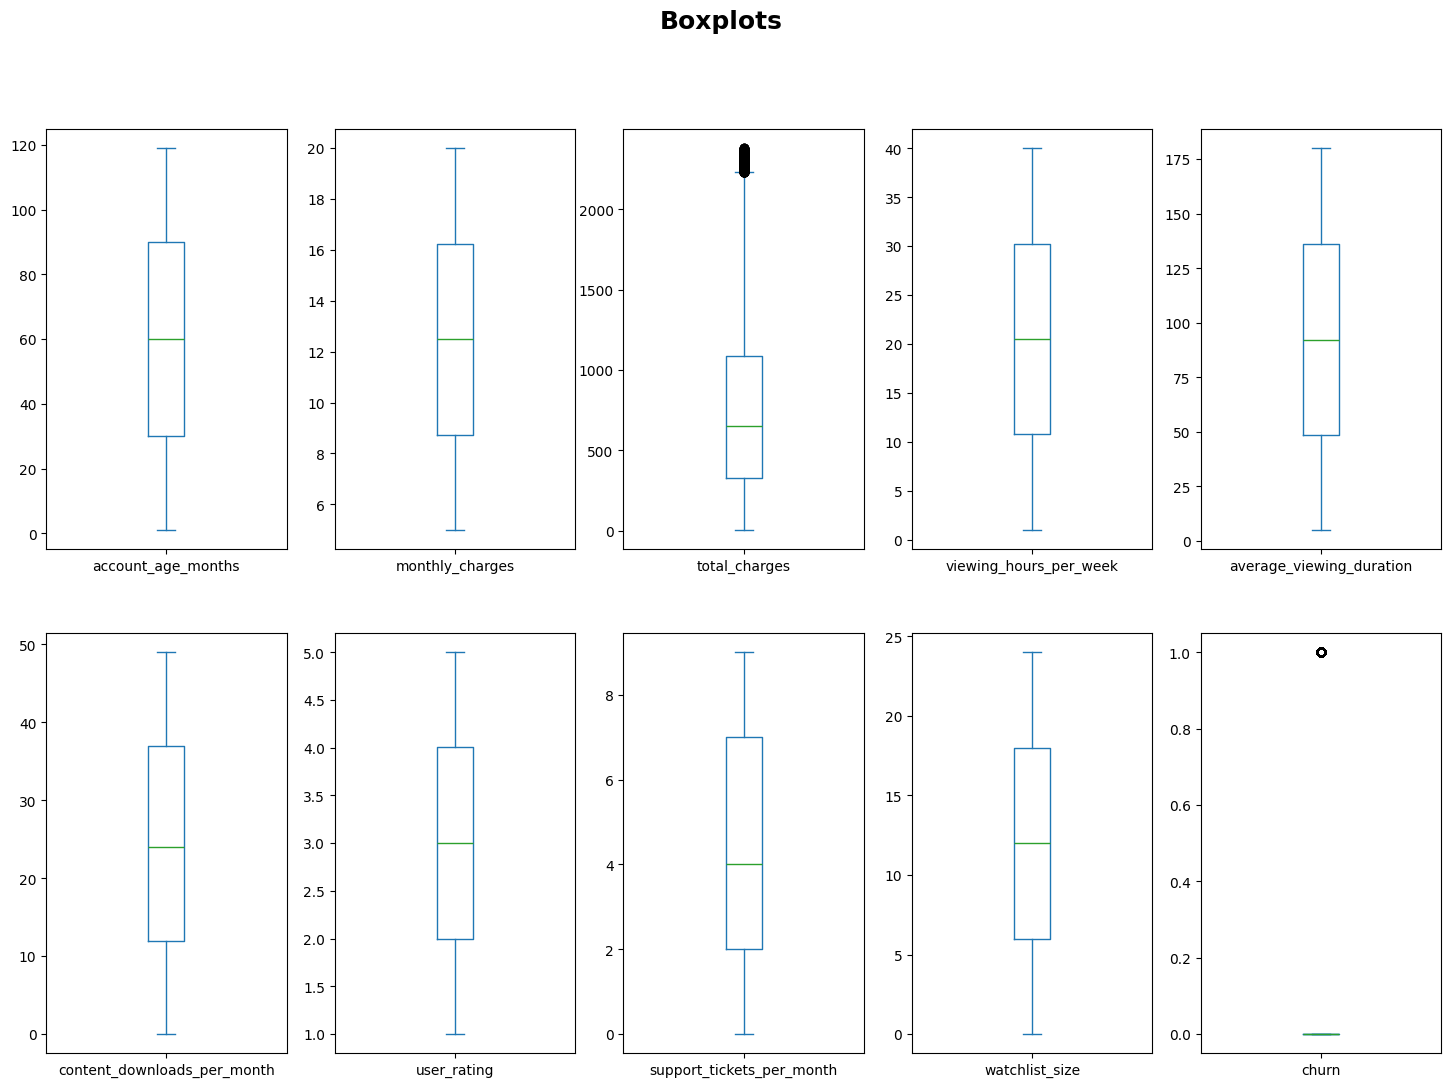

In [17]:
df.plot(kind="box", subplots=True, figsize=(18, 12), layout=(2, 5))
plt.suptitle("Boxplots", fontsize=18, fontweight="bold")
plt.show()

In [18]:
def get_outliers_iqr(data, column):
    # Calculate quartiles and IQR
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1

    # Define upper and lower bounds
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Filter the dataframe for outliers
    outlier_mask = (data[column] < lower_bound) | (data[column] > upper_bound)
    outliers_df = data[outlier_mask]

    return outliers_df

### Total Charges

In [19]:
get_outliers_iqr(df, "total_charges").describe().T

,count,mean,std,min,25%,50%,75%,max
account_age_months,741.0,116.905533,1.856831,112.000000,116.000000,117.000000,119.000000,119.000000
monthly_charges,741.0,19.536936,0.325501,18.736052,19.307749,19.598505,19.816176,19.989489
total_charges,741.0,2283.679755,37.892071,2229.575260,2251.946179,2277.844725,2311.657977,2378.723844
viewing_hours_per_week,741.0,20.060596,11.502882,1.007013,9.701700,20.051935,30.314384,39.996261
average_viewing_duration,741.0,94.341417,50.083525,5.057515,51.406123,93.756439,138.449994,179.787737
content_downloads_per_month,741.0,24.643725,13.796981,0.000000,14.000000,24.000000,36.000000,49.000000
user_rating,741.0,3.071723,1.157492,1.000384,2.100510,3.133668,4.067135,4.995677
support_tickets_per_month,741.0,4.402159,2.850831,0.000000,2.000000,4.000000,7.000000,9.000000
watchlist_size,741.0,12.047233,7.065461,0.000000,6.000000,12.000000,18.000000,24.000000
churn,741.0,0.118758,0.323723,0.000000,0.000000,0.000000,0.000000,1.000000


From a domain knowledge perspective, these outliers are acceptable. No high total charges but low account age or monthly charges for example.

## 2.4 Feature Engineering
At this optional stage of the analysis, no extensive feature engineering or manual feature creation has been performed.

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Exploratory Data Analysis (EDA)</p>

<a id="3"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

## 3.1 Data Visualization
Visualize the data to identify trends, patterns, or anomalies. Suggested visualizations:

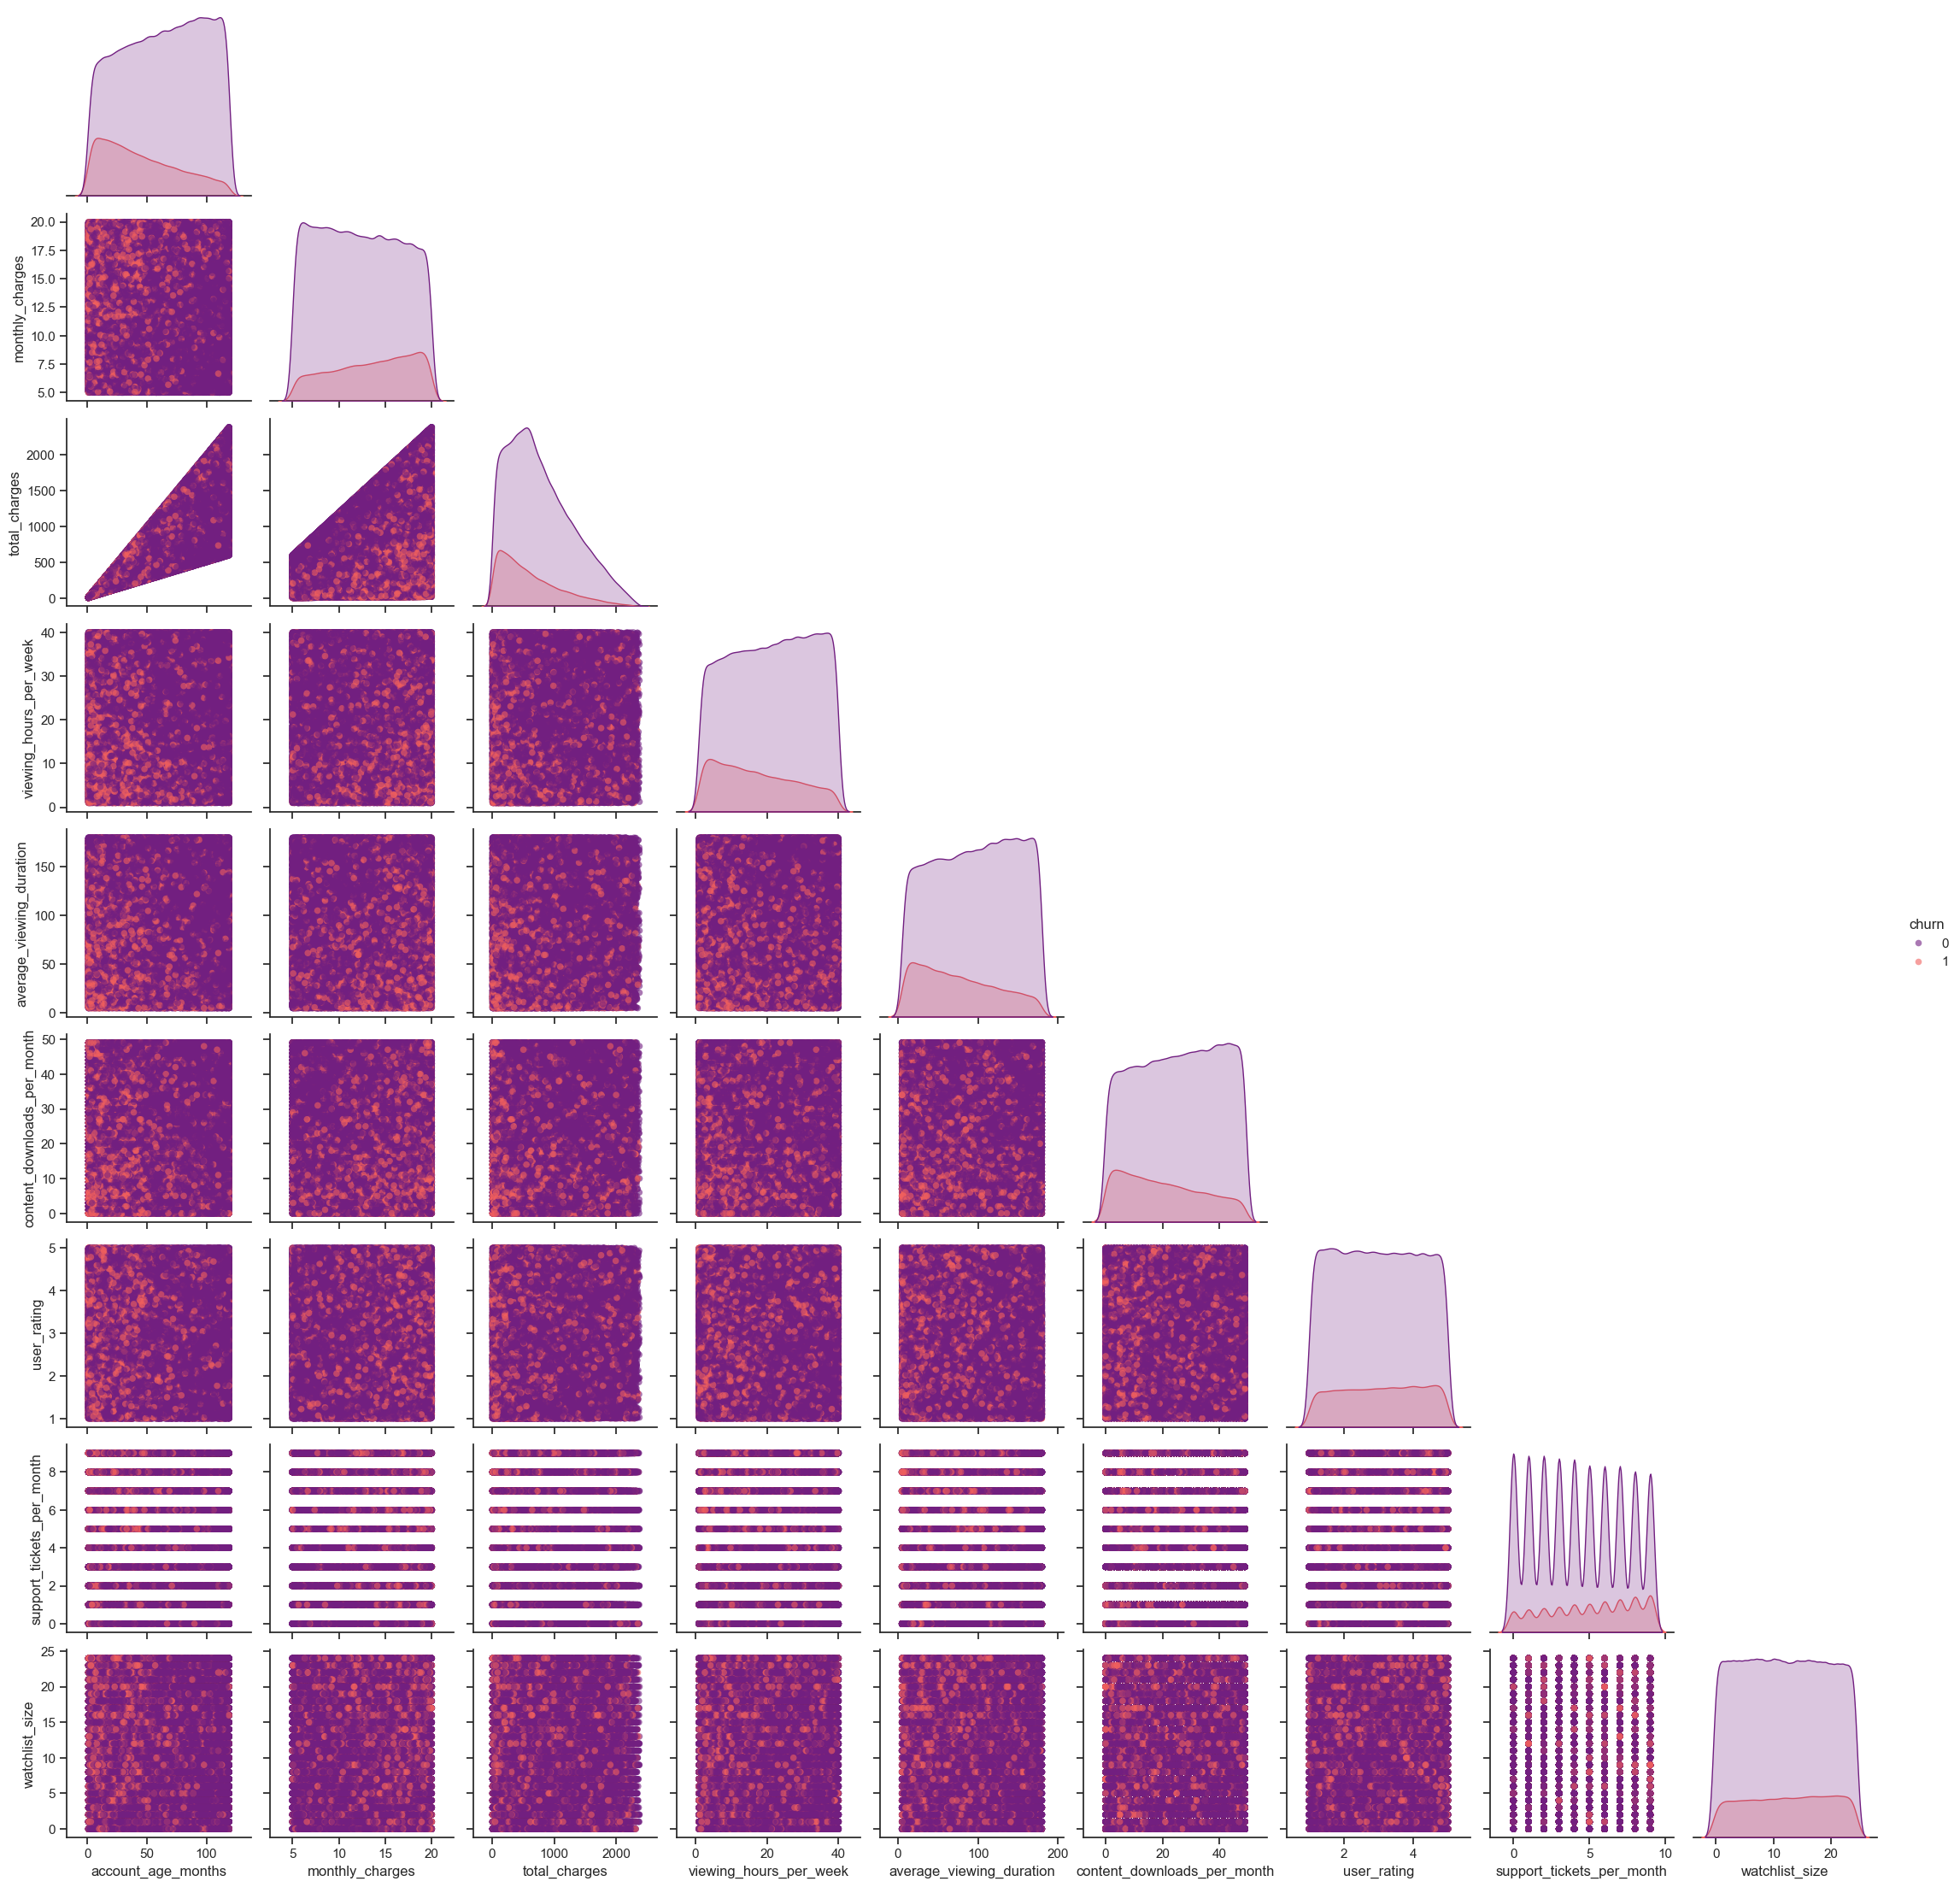

In [20]:
sns.set_theme(style="ticks")

pairplot_fig = sns.pairplot(
    df, 
    hue='churn', 
    palette='magma', 
    corner=True, 
    diag_kind='kde', # Uses Kernel Density Estimate for the diagonal plots
    plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'none'} # Customizes the scatter plots
)

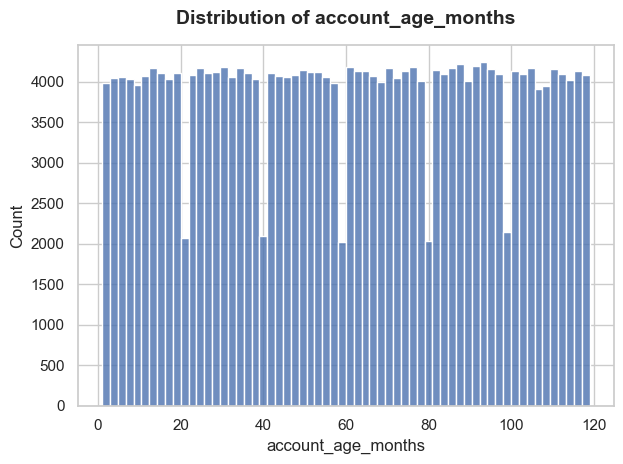

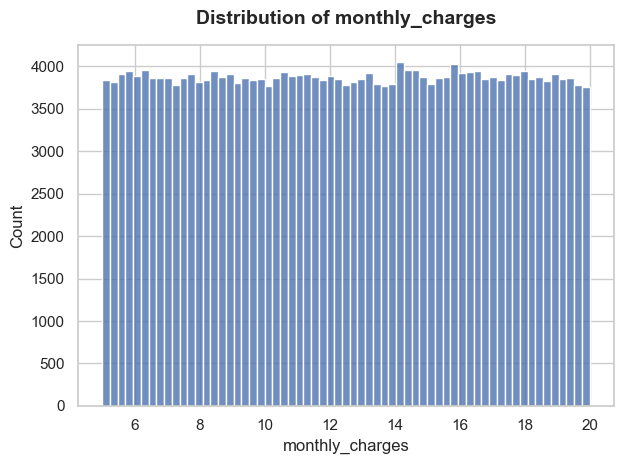

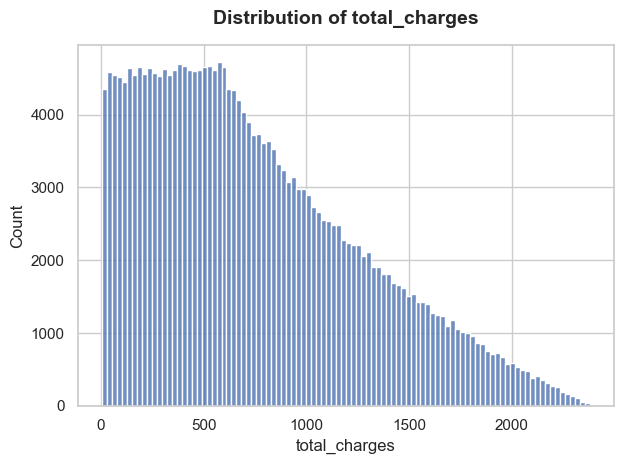

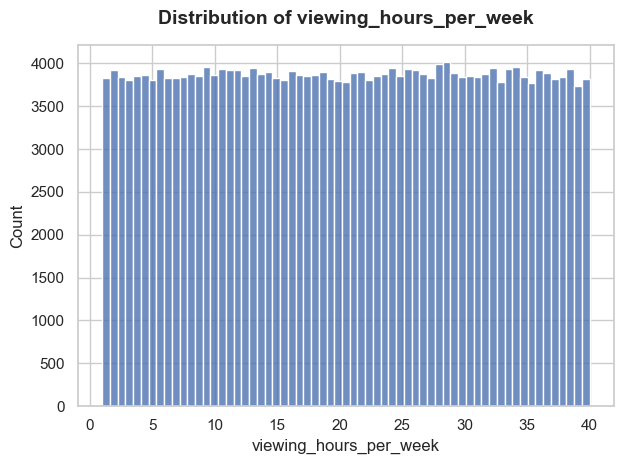

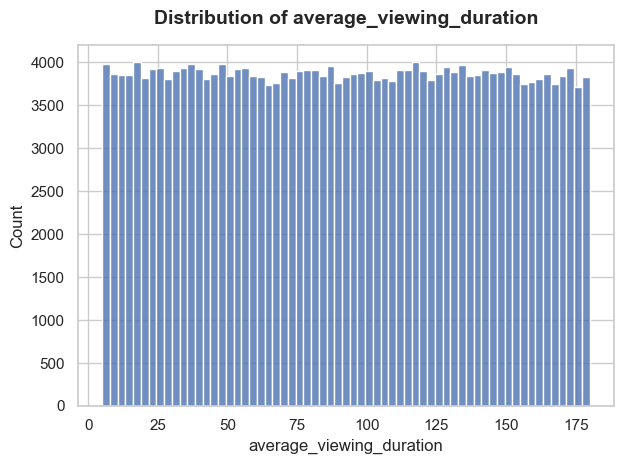

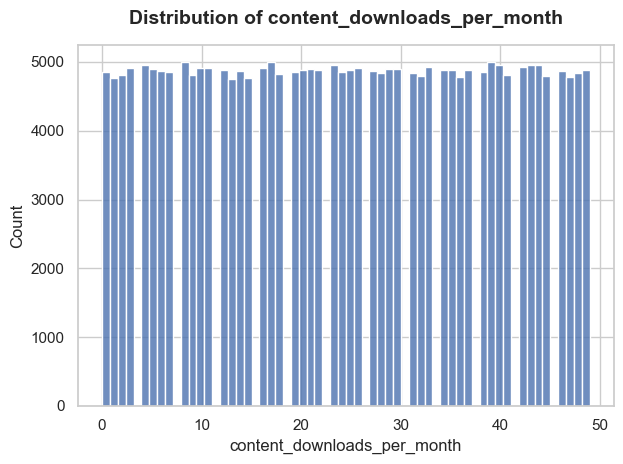

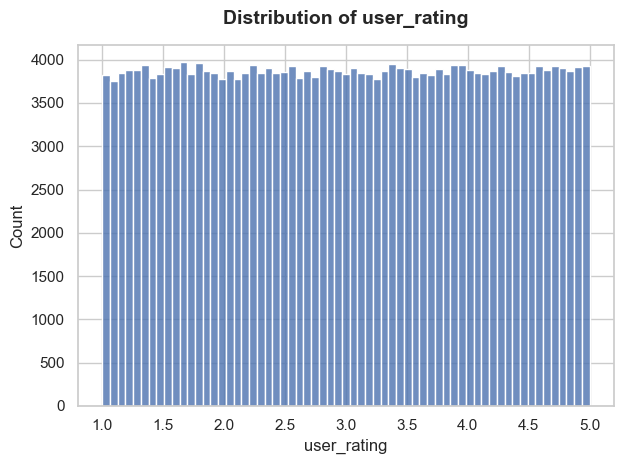

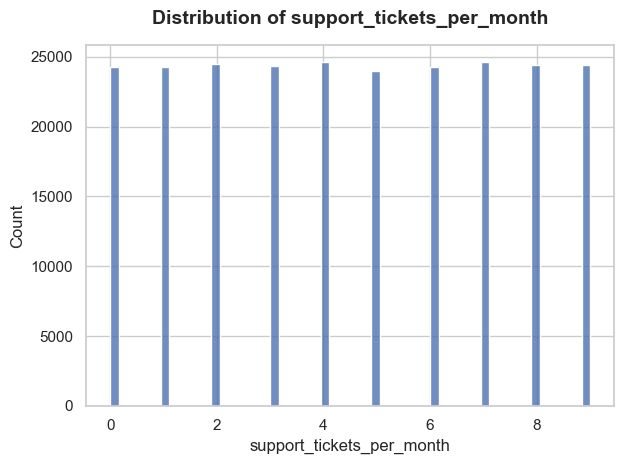

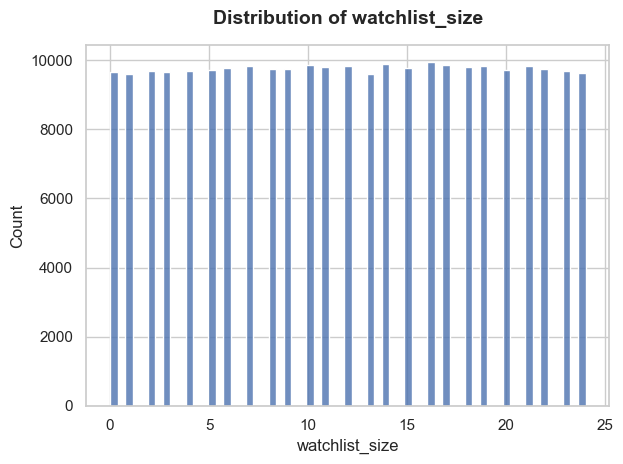

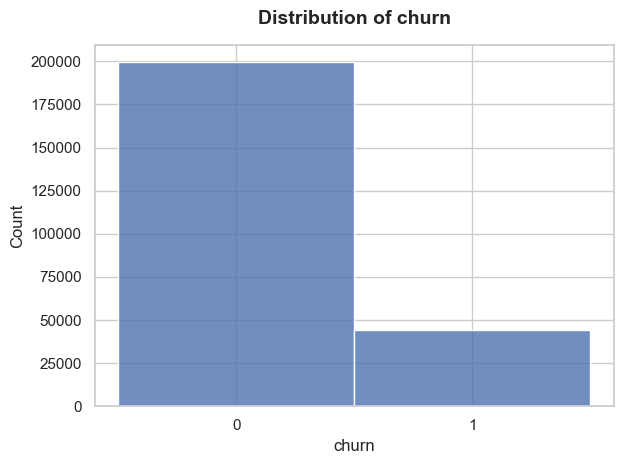

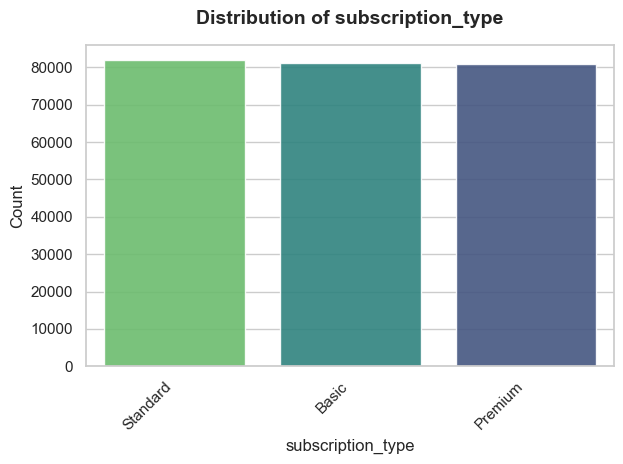

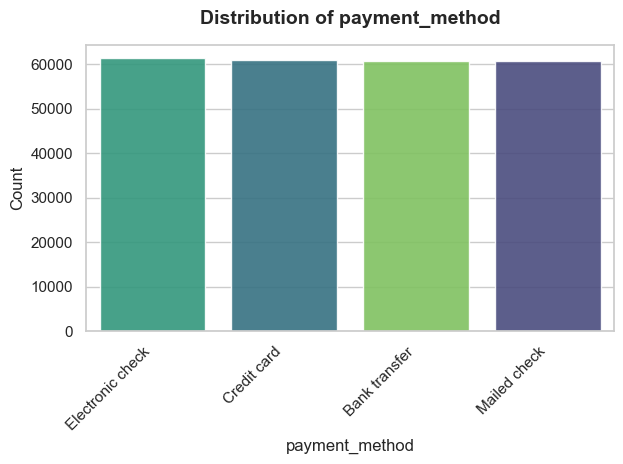

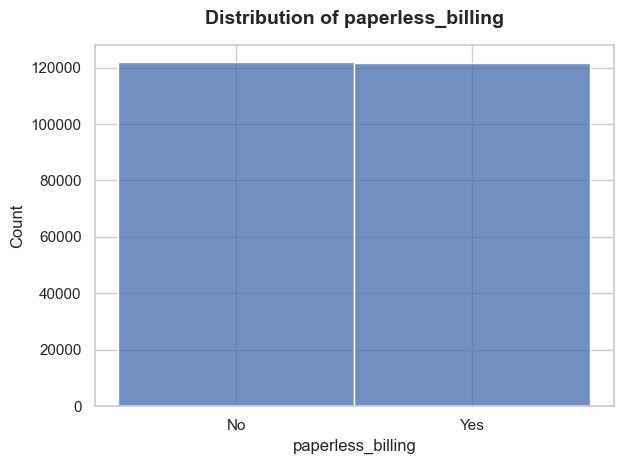

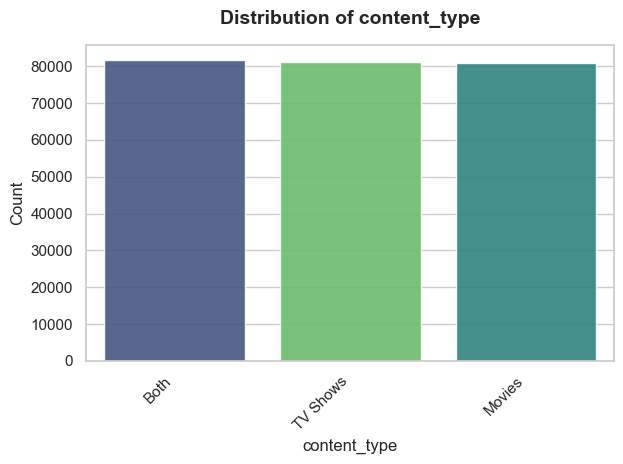

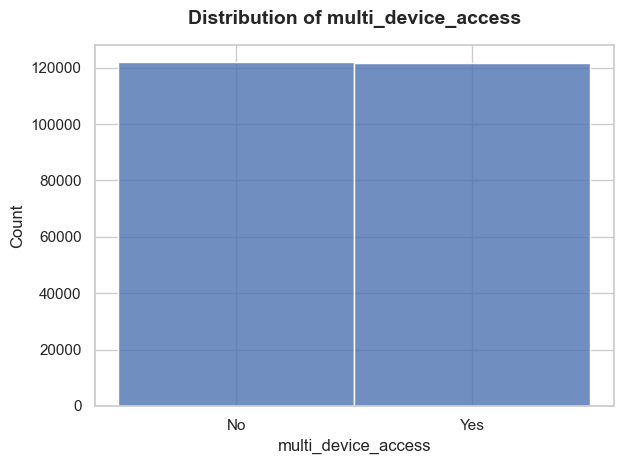

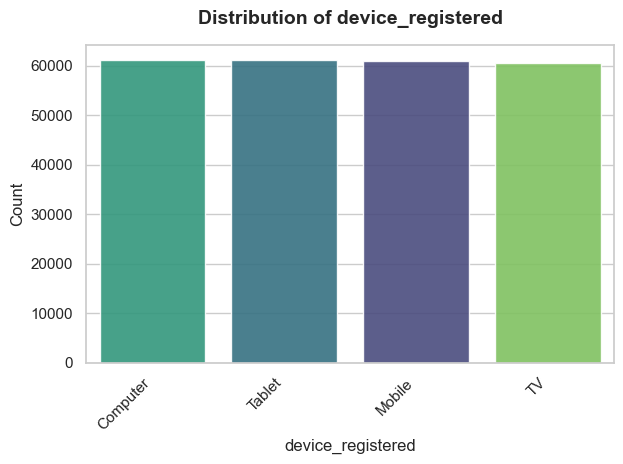

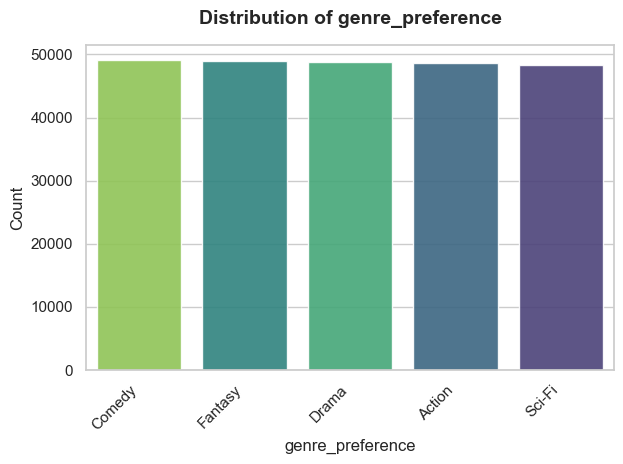

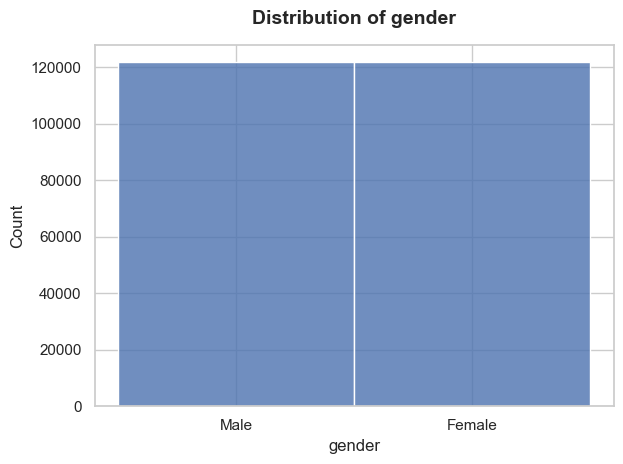

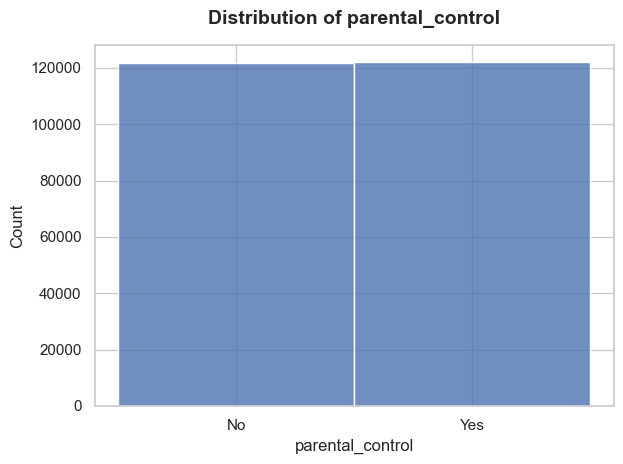

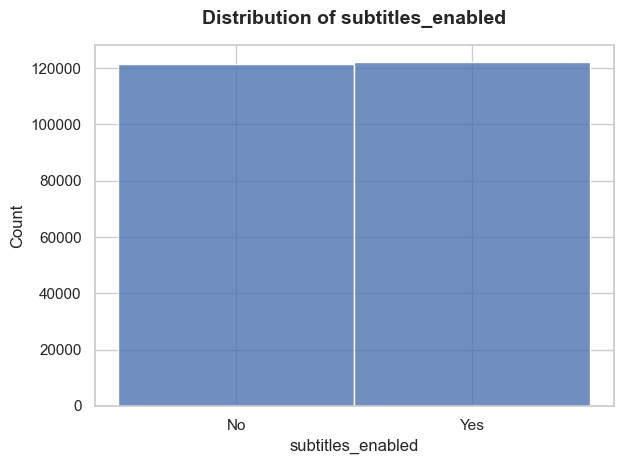

In [170]:
sns.set_theme(style="whitegrid")
sns.set_context("notebook", rc={"figure.figsize": (8, 5), "axes.titlesize": 14, "axes.labelsize": 12})

def plot_distributions(df, is_categorical=False):
    for col in df.columns:
        plt.figure()
        is_binary = (col == "Churn" or df[col].nunique() <= 2)
        
        if is_categorical and not is_binary:
            # Order by frequency 
            order = df[col].value_counts().index
            sns.countplot(data=df, x=col, order=order, hue=col, palette="viridis", legend=False, alpha=0.9)
            plt.xticks(rotation=45, ha="right")
        else:
            sns.histplot(data=df, x=col, color="#4C72B0", edgecolor="w", linewidth=1, alpha=0.8, discrete=is_binary)
            if is_binary:
                plt.xticks([0, 1])
        
        plt.title(f"Distribution of {col}", fontweight="bold", pad=15)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

plot_distributions(num_df, is_categorical=False)
plot_distributions(cat_df, is_categorical=True)

All but Churn, our target variable appear to be balanced.

## 3.2 Correlation Analysis
Analyze correlations between numerical features

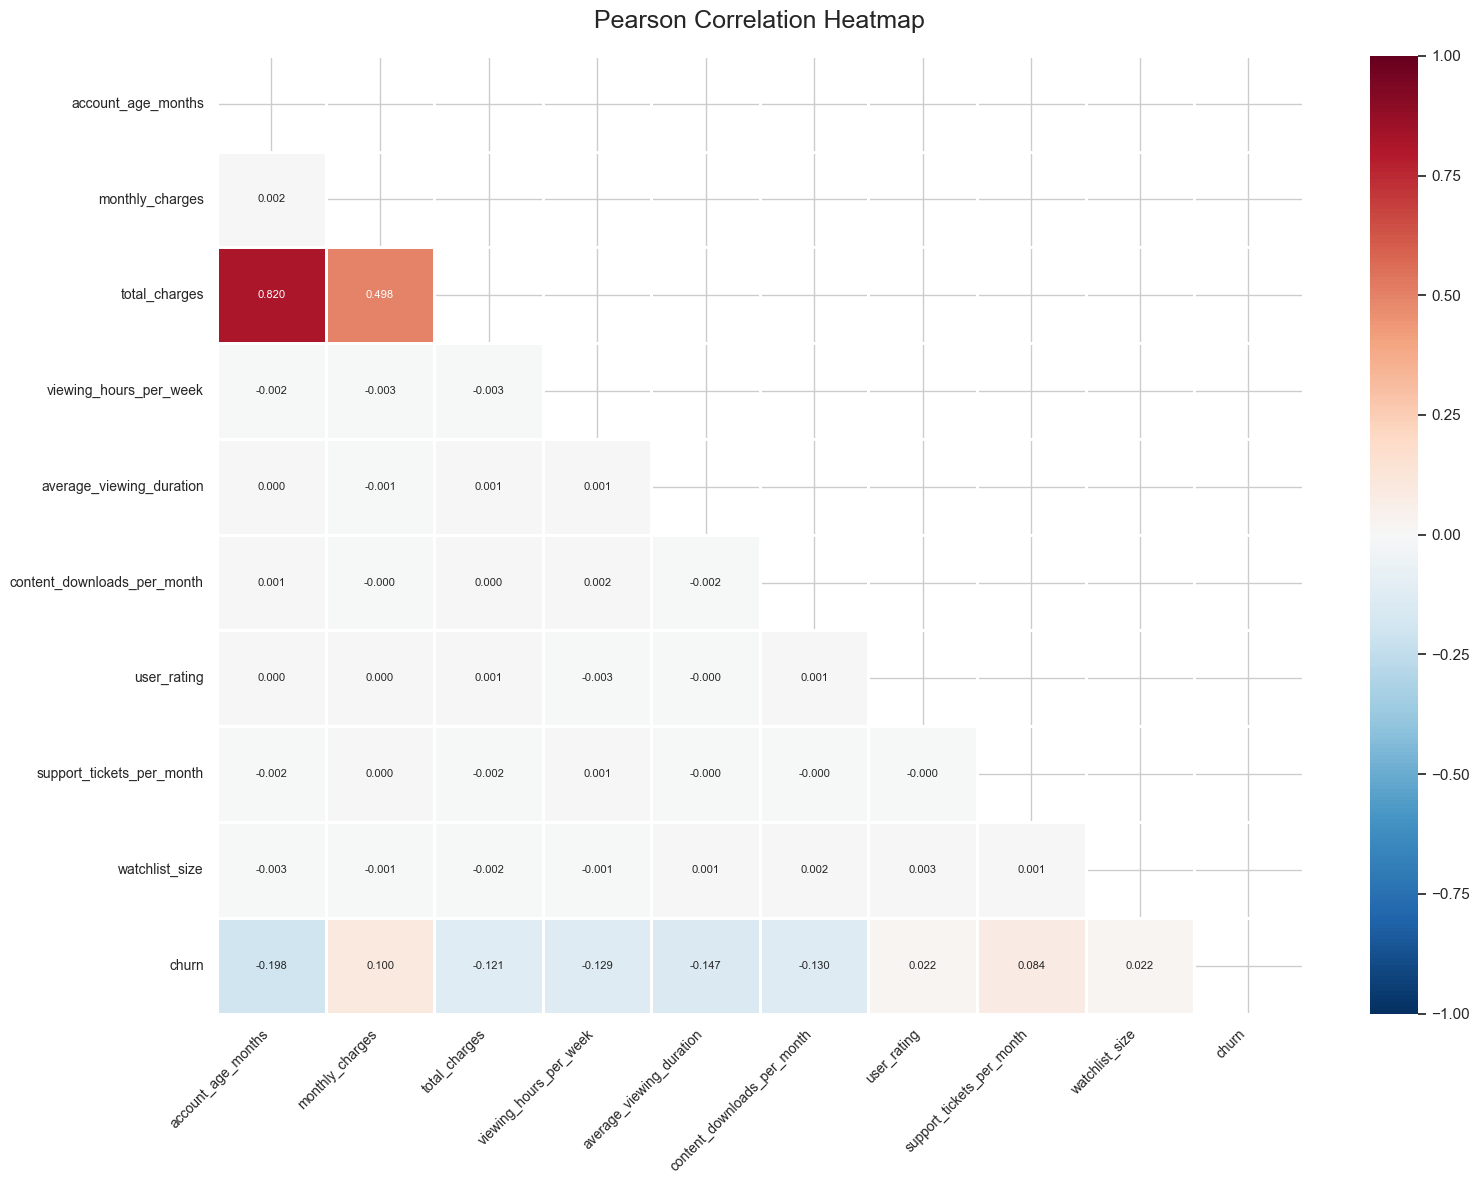

In [171]:
corr_matrix = num_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(16, 12))

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            cmap='RdBu_r',
            vmin=-1, vmax=1,
            fmt='.3f',
            annot_kws={'size': 8},
            linewidths=1,
            linecolor='white')

plt.title('Pearson Correlation Heatmap', fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

There is a high correlation between total charges and account age, so total charges will be dropped.

In [172]:
df = df.drop(columns=["total_charges"])

With respect to Churn, Account Age has the strongest linear correlation followed by Average Viewing Duration.

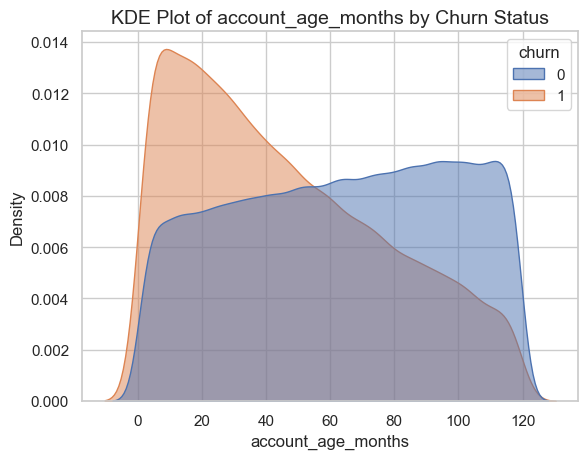

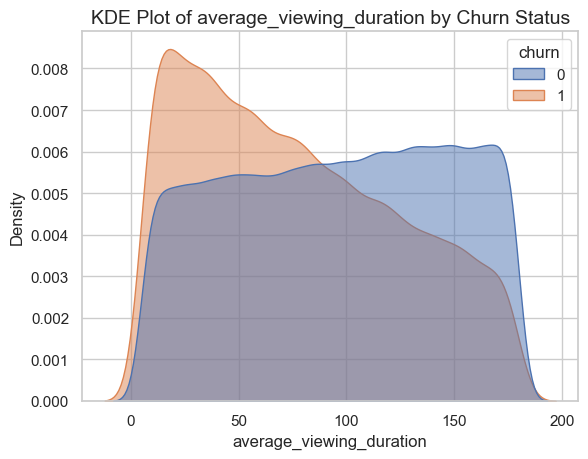

In [173]:
for feature in ["account_age_months", "average_viewing_duration"]:
    sns.kdeplot(
        data=df, x=feature, hue="churn", fill=True, common_norm=False, alpha=0.5
    )
    plt.title(f"KDE Plot of {feature} by Churn Status")
    plt.show()

Churn decreases with user retention and engagement.

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">4. Scaling, Categorical Variables, and Splitting</p>

<a id="4"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>


## 4.1 Encoding Categorical Variables
Handle categorical features:

- **Label Encoding:** For ordinal variables.
- **One-Hot Encoding:** For nominal variables.

In [174]:
df = pd.get_dummies(data=df, columns=cat_df.columns, drop_first=True, dtype="int64")

df.shape

(243787, 28)

In [175]:
df.columns

Index(['account_age_months', 'monthly_charges', 'viewing_hours_per_week',
       'average_viewing_duration', 'content_downloads_per_month',
       'user_rating', 'support_tickets_per_month', 'watchlist_size', 'churn',
       'subscription_type_Premium', 'subscription_type_Standard',
       'payment_method_Credit card', 'payment_method_Electronic check',
       'payment_method_Mailed check', 'paperless_billing_Yes',
       'content_type_Movies', 'content_type_TV Shows',
       'multi_device_access_Yes', 'device_registered_Mobile',
       'device_registered_TV', 'device_registered_Tablet',
       'genre_preference_Comedy', 'genre_preference_Drama',
       'genre_preference_Fantasy', 'genre_preference_Sci-Fi', 'gender_Male',
       'parental_control_Yes', 'subtitles_enabled_Yes'],
      dtype='str')

In [176]:
df.columns = df.columns.str.replace(" ", "_").str.replace("-", "_").str.lower()

df.columns

Index(['account_age_months', 'monthly_charges', 'viewing_hours_per_week',
       'average_viewing_duration', 'content_downloads_per_month',
       'user_rating', 'support_tickets_per_month', 'watchlist_size', 'churn',
       'subscription_type_premium', 'subscription_type_standard',
       'payment_method_credit_card', 'payment_method_electronic_check',
       'payment_method_mailed_check', 'paperless_billing_yes',
       'content_type_movies', 'content_type_tv_shows',
       'multi_device_access_yes', 'device_registered_mobile',
       'device_registered_tv', 'device_registered_tablet',
       'genre_preference_comedy', 'genre_preference_drama',
       'genre_preference_fantasy', 'genre_preference_sci_fi', 'gender_male',
       'parental_control_yes', 'subtitles_enabled_yes'],
      dtype='str')

## 4.2 Splitting
Split the data into training and testing sets to avoid data leakage:

- **Train/Test Split:** Usually a 70/30 or 80/20 split.
- **Stratified Sampling:** If the dataset is imbalanced, ensure stratified sampling of the target variable.

In [177]:
X = df.drop(columns=["churn"])
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

## 4.3 Scaling
Normalize or standardize features to improve model performance, especially for distance-based algorithms (e.g., k-NN, SVM):

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">5. Models</p>

<a id="5"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

## 5.1 Creating Models and Fine-Tuning
Build and evaluate baseline models using different machine learning algorithms. Improve model performance by tuning hyperparameters:

### 5.1.1 Baseline Models

Models will be compared using the AUC ROC. It is preferable to F1 Score for imbalanced datasets.

In [178]:
def log_and_update_results(model_name, fitted_pipeline, X_test, y_test, cv_score, results, optimized, params=None):
    """
    Evaluates a fitted pipeline on the test set, appends metrics along with a single column 
    containing a dictionary of hyperparameters to a results list, and returns an updated, sorted DataFrame.
    """
    # Evaluate the pipeline on the test set
    y_pred_proba = fitted_pipeline.predict_proba(X_test)[:, 1]
    test_roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Auto increment run_id
    existing_runs = sum(1 for row in results if row['model'] == model_name)
    next_run_id = existing_runs + 1
    
    # If params are provided, remove 'model__' prefixes
    clean_params = {}
    if params:
        clean_params = {k.split('__')[-1]: v for k, v in params.items()}
    else:
        # For baseline models
        model_step = fitted_pipeline.named_steps['model']
        clean_params = model_step.get_params()
    
    # Append results
    results.append({
        'model': model_name,
        'run_id': next_run_id,
        'optimized': optimized,
        'cv_roc_auc': cv_score,
        'test_roc_auc': test_roc_auc,
        'hyperparameters': clean_params
    })
    
    # Return updated results sorted by test ROC AUC
    results_df = (
        pd.DataFrame(results)
        .sort_values(by='test_roc_auc', ascending=False)
        .reset_index(drop=True) 
    )

    # Save to CSV
    results_df.to_csv('model_results.csv', index=False)

    return results_df

In [179]:
baseline_models = {
    'Logistic Regression': LogisticRegression(random_state=SEED),
    'Random Forest': RandomForestClassifier(random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(random_state=SEED),
    'AdaBoost': AdaBoostClassifier(random_state=SEED),
    'XGBoost': XGBClassifier(random_state=SEED, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=SEED, verbose=-1),
    'CatBoost': CatBoostClassifier(random_state=SEED, silent=True, allow_writing_files=False)
}

results = []

for name, model in baseline_models.items():
    pipeline = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=SEED)),
        ('model', model)
    ])
    
    cv_scores = cross_val_score(
        pipeline, X_train, y_train, 
        cv=5, scoring='roc_auc', n_jobs=-1
    )
    cv_roc_auc = cv_scores.mean()

    pipeline.fit(X_train, y_train)
    
    results_df = log_and_update_results(
        model_name=name,
        fitted_pipeline=pipeline,
        X_test=X_test,
        y_test=y_test,
        cv_score=cv_roc_auc,
        results=results,
        optimized=False
    )

    clear_output(wait=True)
    display(results_df)

,model,run_id,optimized,cv_roc_auc,test_roc_auc,hyperparameters
0,Logistic Regression,1,False,0.748973,0.754572,"{'C': 1.0, 'class_weight': None, 'dual': False..."
1,LightGBM,1,False,0.742631,0.747503,"{'boosting_type': 'gbdt', 'class_weight': None..."
2,CatBoost,1,False,0.739716,0.745124,"{'silent': True, 'allow_writing_files': False,..."
3,XGBoost,1,False,0.734367,0.741371,"{'objective': 'binary:logistic', 'base_score':..."
4,Gradient Boosting,1,False,0.731704,0.736484,"{'ccp_alpha': 0.0, 'criterion': 'friedman_mse'..."
5,AdaBoost,1,False,0.724959,0.729883,"{'estimator': None, 'learning_rate': 1.0, 'n_e..."
6,Random Forest,1,False,0.720203,0.726167,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."


## 5.2 Model Comparisons
Compare the performance of different models after hyperparameter tuning.

### Logistic Regression

In [180]:
pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=SEED)),
    ('model', LogisticRegression(random_state=SEED))
])

param_grid = {
    #'model__C': np.logspace(-4,4,20),
    #'model__solver': ['lbfgs','newton-cg','liblinear','sag','saga']
    'model__C': [0.6, 0.7, 0.8, 0.9, 1, 1.1],
    'model__l1_ratio': np.linspace(0, 1, 11),
    'model__solver': ['saga']
}

clf =  GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

clf.fit(X_train, y_train)

print("=== Best Hyperparameters Found ===")
for param, value in clf.best_params_.items():
    # Cleans 'model__C' to just 'C' for readability
    clean_name = param.split('__')[-1]
    print(f" - {clean_name}: {value}")
print("==================================\n")

results_df = log_and_update_results(
        model_name="Logistic Regression",
        fitted_pipeline=clf.best_estimator_,
        X_test=X_test,
        y_test=y_test,
        cv_score=clf.best_score_,
        results=results,
        optimized=True,
        params=clf.best_params_
    )

results_df[results_df['model'] == "Logistic Regression"]

Fitting 3 folds for each of 66 candidates, totalling 198 fits
=== Best Hyperparameters Found ===
 - C: 1.1
 - l1_ratio: 0.6000000000000001
 - solver: saga



,model,run_id,optimized,cv_roc_auc,test_roc_auc,hyperparameters
0,Logistic Regression,1,False,0.748973,0.754572,"{'C': 1.0, 'class_weight': None, 'dual': False..."
1,Logistic Regression,2,True,0.748945,0.754571,"{'C': 1.1, 'l1_ratio': 0.6000000000000001, 'so..."


### Random Forest

In [181]:
pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=SEED)),
    ('model', RandomForestClassifier(random_state=SEED))
])

param_grid = {
    "model__max_depth": range(2, 15),
    "model__n_estimators": range(10, 50),
    "model__min_samples_split": [2, 3, 4],
    "model__max_features": ["sqrt", "log", None,  "auto"],
    "model__criterion": ["gini", "entropy"]
}

clf = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring='roc_auc',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

clf.fit(X_train, y_train)

print("=== Best Hyperparameters Found ===")
for param, value in clf.best_params_.items():
    clean_name = param.split('__')[-1]
    print(f" - {clean_name}: {value}")
print("==================================\n")

results_df = log_and_update_results(
        model_name="Random Forest",
        fitted_pipeline=clf.best_estimator_,
        X_test=X_test,
        y_test=y_test,
        cv_score=clf.best_score_,
        results=results,
        optimized=True,
        params=clf.best_params_
    )

results_df[results_df['model'] == "Random Forest"]

Fitting 3 folds for each of 20 candidates, totalling 60 fits
=== Best Hyperparameters Found ===
 - n_estimators: 40
 - min_samples_split: 4
 - max_features: sqrt
 - max_depth: 13
 - criterion: gini



,model,run_id,optimized,cv_roc_auc,test_roc_auc,hyperparameters
7,Random Forest,2,True,0.722440,0.728395,"{'n_estimators': 40, 'min_samples_split': 4, '..."
8,Random Forest,1,False,0.720203,0.726167,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."


### Gradient Boosting

In [182]:
pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=SEED)),
    ('model', GradientBoostingClassifier(random_state=SEED))
])

param_grid = {
    'model__n_estimators': randint(50, 300),
    'model__learning_rate': uniform(0.01, 0.29),
    'model__max_depth': [3, 5, 8, 10],
    'model__min_samples_split': randint(2, 20),
    'model__min_samples_leaf': randint(1, 10),
    'model__subsample': uniform(0.5, 0.5)
}

clf = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring='roc_auc',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

clf.fit(X_train, y_train)

print("\n=== Best Hyperparameters Found ===")
for param, value in clf.best_params_.items():
    clean_name = param.split('__')[-1]
    print(f" - {clean_name}: {value}")
print("==================================\n")

results_df = log_and_update_results(
    model_name="Gradient Boosting",
    fitted_pipeline=clf.best_estimator_,
    X_test=X_test,
    y_test=y_test,
    cv_score=clf.best_score_,
    results=results,
    optimized=True,
    params=clf.best_params_
)

results_df[results_df['model'] == "Gradient Boosting"]

Fitting 3 folds for each of 20 candidates, totalling 60 fits

=== Best Hyperparameters Found ===
 - learning_rate: 0.2464838142519019
 - max_depth: 3
 - min_samples_leaf: 8
 - min_samples_split: 4
 - n_estimators: 212
 - subsample: 0.8856351733429728



,model,run_id,optimized,cv_roc_auc,test_roc_auc,hyperparameters
2,Gradient Boosting,2,True,0.741224,0.748072,"{'learning_rate': 0.2464838142519019, 'max_dep..."
6,Gradient Boosting,1,False,0.731704,0.736484,"{'ccp_alpha': 0.0, 'criterion': 'friedman_mse'..."


### AdaBoost

In [183]:
pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=SEED)),
    ('model', AdaBoostClassifier(random_state=SEED))
])

param_grid = {
    'model__n_estimators': randint(50, 500),
    'model__learning_rate': uniform(0.01, 1.5)
}

clf = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring='roc_auc',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

clf.fit(X_train, y_train)

print("\n=== Best Hyperparameters Found ===")
for param, value in clf.best_params_.items():
    clean_name = param.split('__')[-1]
    print(f" - {clean_name}: {value}")
print("==================================\n")

results_df = log_and_update_results(
    model_name="AdaBoost",
    fitted_pipeline=clf.best_estimator_,
    X_test=X_test,
    y_test=y_test,
    cv_score=clf.best_score_,
    results=results,
    optimized=True,
    params=clf.best_params_
)

results_df[results_df['model'] == "AdaBoost"]

Fitting 3 folds for each of 20 candidates, totalling 60 fits

=== Best Hyperparameters Found ===
 - learning_rate: 1.2586639612006325
 - n_estimators: 343



,model,run_id,optimized,cv_roc_auc,test_roc_auc,hyperparameters
6,AdaBoost,2,True,0.733070,0.739249,"{'learning_rate': 1.2586639612006325, 'n_estim..."
8,AdaBoost,1,False,0.724959,0.729883,"{'estimator': None, 'learning_rate': 1.0, 'n_e..."


### XGBoost

In [184]:
pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=SEED)),
    ('model', XGBClassifier(random_state=SEED, eval_metric='logloss'))
])

param_grid = {
    'model__n_estimators': randint(50, 400),
    'model__learning_rate': uniform(0.01, 0.29),
    'model__max_depth': [3, 4, 5, 6, 8, 10],
    'model__min_child_weight': randint(1, 10),
    'model__subsample': uniform(0.5, 0.5),
    'model__colsample_bytree': uniform(0.5, 0.5), 
    'model__gamma': uniform(0, 5)
}

clf = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring='roc_auc',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

clf.fit(X_train, y_train)

print("\n=== Best Hyperparameters Found ===")
for param, value in clf.best_params_.items():
    clean_name = param.split('__')[-1]
    print(f" - {clean_name}: {value}")
print("==================================\n")

results_df = log_and_update_results(
    model_name="XGBoost",
    fitted_pipeline=clf.best_estimator_,
    X_test=X_test,
    y_test=y_test,
    cv_score=clf.best_score_,
    results=results,
    optimized=True,
    params=clf.best_params_
)

results_df[results_df['model'] == "XGBoost"]

Fitting 3 folds for each of 20 candidates, totalling 60 fits

=== Best Hyperparameters Found ===
 - colsample_bytree: 0.5499874579090014
 - gamma: 2.2962444598293357
 - learning_rate: 0.10677549723031632
 - max_depth: 5
 - min_child_weight: 6
 - n_estimators: 358
 - subsample: 0.9849549260809971



,model,run_id,optimized,cv_roc_auc,test_roc_auc,hyperparameters
2,XGBoost,2,True,0.742182,0.749048,"{'colsample_bytree': 0.5499874579090014, 'gamm..."
6,XGBoost,1,False,0.734367,0.741371,"{'objective': 'binary:logistic', 'base_score':..."


### LightGBM

In [185]:
pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=SEED)),
    ('model', LGBMClassifier(random_state=SEED, verbose=-1))
])

param_grid = {
    'model__n_estimators': randint(50, 400),
    'model__learning_rate': uniform(0.01, 0.29),
    'model__num_leaves': randint(20, 150),
    'model__max_depth': [-1, 3, 5, 8, 12, 15],
    'model__min_child_samples': randint(10, 100), 
    'model__subsample': uniform(0.5, 0.5),
    'model__colsample_bytree': uniform(0.5, 0.5),
    'model__reg_alpha': uniform(0, 10),
    'model__reg_lambda': uniform(0, 10)
}

clf = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring='roc_auc',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

clf.fit(X_train, y_train)

print("\n=== Best Hyperparameters Found ===")
for param, value in clf.best_params_.items():
    clean_name = param.split('__')[-1]
    print(f" - {clean_name}: {value}")
print("==================================\n")

results_df = log_and_update_results(
    model_name="LightGBM",
    fitted_pipeline=clf.best_estimator_,
    X_test=X_test,
    y_test=y_test,
    cv_score=clf.best_score_,
    results=results,
    optimized=True,
    params=clf.best_params_
)

results_df[results_df['model'] == "LightGBM"]

Fitting 3 folds for each of 20 candidates, totalling 60 fits

=== Best Hyperparameters Found ===
 - colsample_bytree: 0.6558555380447055
 - learning_rate: 0.16081972614156514
 - max_depth: 3
 - min_child_samples: 13
 - n_estimators: 359
 - num_leaves: 63
 - reg_alpha: 9.394989415641891
 - reg_lambda: 8.948273504276488
 - subsample: 0.7989499894055425



,model,run_id,optimized,cv_roc_auc,test_roc_auc,hyperparameters
2,LightGBM,2,True,0.744042,0.749816,"{'colsample_bytree': 0.6558555380447055, 'lear..."
5,LightGBM,1,False,0.742631,0.747503,"{'boosting_type': 'gbdt', 'class_weight': None..."


### CatBoost

In [186]:
pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=SEED)),
    ('model', CatBoostClassifier(random_state=SEED, silent=True, allow_writing_files=False))
])

param_grid = {
    'model__iterations': randint(50, 400),
    'model__learning_rate': uniform(0.01, 0.29),
    'model__depth': [4, 5, 6, 7, 8, 10],
    'model__l2_leaf_reg': uniform(1, 10),
    'model__random_strength': uniform(0, 2),
    'model__border_count': randint(32, 255)
}

clf = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=15,
    cv=3,
    scoring='roc_auc',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

clf.fit(X_train, y_train)

print("\n=== Best Hyperparameters Found ===")
for param, value in clf.best_params_.items():
    clean_name = param.split('__')[-1]
    print(f" - {clean_name}: {value}")
print("==================================\n")

results_df = log_and_update_results(
    model_name="CatBoost",
    fitted_pipeline=clf.best_estimator_,
    X_test=X_test,
    y_test=y_test,
    cv_score=clf.best_score_,
    results=results,
    optimized=True,
    params=clf.best_params_
)

results_df[results_df['model'] == "CatBoost"]

Fitting 3 folds for each of 15 candidates, totalling 45 fits

=== Best Hyperparameters Found ===
 - border_count: 252
 - depth: 5
 - iterations: 267
 - l2_leaf_reg: 5.497541333697656
 - learning_rate: 0.12459356844052617
 - random_strength: 1.8533177315875884



,model,run_id,optimized,cv_roc_auc,test_roc_auc,hyperparameters
2,CatBoost,2,True,0.746153,0.752186,"{'border_count': 252, 'depth': 5, 'iterations'..."
7,CatBoost,1,False,0.739716,0.745124,"{'silent': True, 'allow_writing_files': False,..."


### SVM

In [ ]:
'''
takes too long to run

pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=SEED)),
    ('model', SVC(random_state=SEED, probability=True)) 
])

param_grid = [
    {
        # Linear Kernel: Only tunes the regularization margin (C)
        'model__kernel': ['linear'],
        'model__C': loguniform(1e-3, 1e2)
    },
    {
        # RBF & Sigmoid Kernels: Tunes margin (C) and decision boundary scale (gamma)
        'model__kernel': ['rbf', 'sigmoid'],
        'model__C': loguniform(1e-3, 1e2),
        'model__gamma': ['scale', 'auto'] 
    },
    {
        # Polynomial Kernel: Tunes margin, scale, and the polynomial exponent (degree)
        'model__kernel': ['poly'],
        'model__degree': [2, 3, 4],
        'model__C': loguniform(1e-3, 1e2),
        'model__gamma': ['scale', 'auto']
    }
]

clf = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=2, 
    cv=2,
    scoring='roc_auc',
    random_state=SEED,
    n_jobs=-1,
    verbose=2
)

clf.fit(X_train, y_train)

print("\n=== Best Hyperparameters Found ===")
for param, value in clf.best_params_.items():
    clean_name = param.split('__')[-1]
    print(f" - {clean_name}: {value}")
print("==================================\n")

results_df = log_and_update_results(
    model_name="SVM",
    fitted_pipeline=clf.best_estimator_,
    X_test=X_test,
    y_test=y_test,
    cv_score=clf.best_score_,
    results=results, 
    optimized=True,
    params=clf.best_params_
)

results_df[results_df['model'] == "SVM"]
'''

Fitting 2 folds for each of 2 candidates, totalling 4 fits


KeyboardInterrupt: 

## 5.3 Final Model
Choose the best-performing model based on your evaluations and fine-tuning.

In [195]:
results_df

,model,run_id,optimized,cv_roc_auc,test_roc_auc,hyperparameters
0,Logistic Regression,1,False,0.748973,0.754572,"{'C': 1.0, 'class_weight': None, 'dual': False..."
1,Logistic Regression,2,True,0.748945,0.754571,"{'C': 1.1, 'l1_ratio': 0.6000000000000001, 'so..."
2,CatBoost,2,True,0.746153,0.752186,"{'border_count': 252, 'depth': 5, 'iterations'..."
3,LightGBM,2,True,0.744042,0.749816,"{'colsample_bytree': 0.6558555380447055, 'lear..."
4,XGBoost,2,True,0.742182,0.749048,"{'colsample_bytree': 0.5499874579090014, 'gamm..."
5,Gradient Boosting,2,True,0.741224,0.748072,"{'learning_rate': 0.2464838142519019, 'max_dep..."
6,LightGBM,1,False,0.742631,0.747503,"{'boosting_type': 'gbdt', 'class_weight': None..."
7,CatBoost,1,False,0.739716,0.745124,"{'silent': True, 'allow_writing_files': False,..."
8,XGBoost,1,False,0.734367,0.741371,"{'objective': 'binary:logistic', 'base_score':..."
9,AdaBoost,2,True,0.733070,0.739249,"{'learning_rate': 1.2586639612006325, 'n_estim..."


The best performing model is the baseline Logistic Regression model with an ROC AUC of 0.754572. This model will be used to get feature importance.

## 5.4 Feature Importance
Analyze and explain the most important features:

In [196]:
baseline_lr_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=SEED)),
    ('model', LogisticRegression(random_state=SEED, max_iter=1000))
])

baseline_lr_pipeline.fit(X_train, y_train)

lr_model = baseline_lr_pipeline.named_steps['model']

feature_names = X_train.columns

coefficients = lr_model.coef_[0]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute_Importance': np.abs(coefficients)
})

importance_df = importance_df.sort_values(by='Absolute_Importance', ascending=False).reset_index(drop=True)

importance_df

,Feature,Coefficient,Absolute_Importance
0,account_age_months,-0.670408,0.670408
1,average_viewing_duration,-0.508880,0.508880
2,content_downloads_per_month,-0.439312,0.439312
3,viewing_hours_per_week,-0.438151,0.438151
4,monthly_charges,0.340703,0.340703
5,support_tickets_per_month,0.289703,0.289703
6,subscription_type_premium,-0.145370,0.145370
7,genre_preference_comedy,0.088794,0.088794
8,genre_preference_sci_fi,0.083025,0.083025
9,user_rating,0.072962,0.072962


Account age, user engagement with features related viewing duration and downloads, along with monthly price are the most important features.

## 5.5 Create a Model with Fewer Features (if necessary)

### Logistic Regression

In [ ]:
top_7_features = importance_df.head(7)['Feature'].tolist()

X_train_top7 = X_train[top_7_features]
X_test_top7 = X_test[top_7_features]

top7_lr_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=SEED)),
    ('model', LogisticRegression(random_state=SEED, max_iter=1000))
])

cv_scores = cross_val_score(
    top7_lr_pipeline, 
    X_train_top7, y_train, 
    cv=10, 
    scoring='roc_auc', 
    n_jobs=-1
)
cv_roc_auc = cv_scores.mean()

top7_lr_pipeline.fit(X_train_top7, y_train)

results_df = log_and_update_results(
    model_name="Logistic Regression (Top 7 Features)",
    fitted_pipeline=top7_lr_pipeline,
    X_test=X_test_top7,
    y_test=y_test,
    cv_score=cv_roc_auc,
    results=results,
    optimized=False,
)

results_df

,model,run_id,optimized,cv_roc_auc,test_roc_auc,hyperparameters
0,Logistic Regression,1,False,0.748973,0.754572,"{'C': 1.0, 'class_weight': None, 'dual': False..."
1,Logistic Regression,2,True,0.748945,0.754571,"{'C': 1.1, 'l1_ratio': 0.6000000000000001, 'so..."
2,CatBoost,2,True,0.746153,0.752186,"{'border_count': 252, 'depth': 5, 'iterations'..."
3,Logistic Regression (Top 7 Features),1,False,0.745628,0.751662,"{'C': 1.0, 'class_weight': None, 'dual': False..."
4,LightGBM,2,True,0.744042,0.749816,"{'colsample_bytree': 0.6558555380447055, 'lear..."
5,XGBoost,2,True,0.742182,0.749048,"{'colsample_bytree': 0.5499874579090014, 'gamm..."
6,Gradient Boosting,2,True,0.741224,0.748072,"{'learning_rate': 0.2464838142519019, 'max_dep..."
7,LightGBM,1,False,0.742631,0.747503,"{'boosting_type': 'gbdt', 'class_weight': None..."
8,CatBoost,1,False,0.739716,0.745124,"{'silent': True, 'allow_writing_files': False,..."
9,XGBoost,1,False,0.734367,0.741371,"{'objective': 'binary:logistic', 'base_score':..."


### CatBoost

In [206]:
tuned_catboost_model = CatBoostClassifier(
    iterations=267,
    learning_rate=0.12459356844052617,
    depth=5,
    l2_leaf_reg=5.497541333697656,
    random_strength=1.8533177315875884,
    border_count=252,
    random_state=SEED,
    silent=True,
    allow_writing_files=False
)

top7_cb_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=SEED)),
    ('model', tuned_catboost_model)
])

cv_scores = cross_val_score(
    top7_cb_pipeline, 
    X_train_top7, y_train, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1
)

cv_roc_auc = cv_scores.mean()

top7_cb_pipeline.fit(X_train_top7, y_train)

best_params_dict = {
    'iterations': 267,
    'learning_rate': 0.12459356844052617,
    'depth': 5,
    'l2_leaf_reg': 5.497541333697656,
    'random_strength': 1.8533177315875884,
    'border_count': 252,
    'selected_features': top_7_features
}

results_df = log_and_update_results(
    model_name="CatBoost (Top 7 Features)",
    fitted_pipeline=top7_cb_pipeline,
    X_test=X_test_top7,
    y_test=y_test,
    cv_score=cv_roc_auc,
    results=results, 
    optimized=True,
    params=best_params_dict
)

results_df

,model,run_id,optimized,cv_roc_auc,test_roc_auc,hyperparameters
0,Logistic Regression,1,False,0.748973,0.754572,"{'C': 1.0, 'class_weight': None, 'dual': False..."
1,Logistic Regression,2,True,0.748945,0.754571,"{'C': 1.1, 'l1_ratio': 0.6000000000000001, 'so..."
2,CatBoost,2,True,0.746153,0.752186,"{'border_count': 252, 'depth': 5, 'iterations'..."
3,Logistic Regression (Top 7 Features),1,False,0.745628,0.751662,"{'C': 1.0, 'class_weight': None, 'dual': False..."
4,LightGBM,2,True,0.744042,0.749816,"{'colsample_bytree': 0.6558555380447055, 'lear..."
5,CatBoost (Top 7 Features),1,True,0.742629,0.749308,"{'iterations': 267, 'learning_rate': 0.1245935..."
6,XGBoost,2,True,0.742182,0.749048,"{'colsample_bytree': 0.5499874579090014, 'gamm..."
7,Gradient Boosting,2,True,0.741224,0.748072,"{'learning_rate': 0.2464838142519019, 'max_dep..."
8,LightGBM,1,False,0.742631,0.747503,"{'boosting_type': 'gbdt', 'class_weight': None..."
9,CatBoost,1,False,0.739716,0.745124,"{'silent': True, 'allow_writing_files': False,..."


## 5.6 Pickle the Model
Save the final model for future deployment:

In [ ]:
model_filename = 'logistic_regression_model.pkl'

# Save the fitted pipeline
with open(model_filename, 'wb') as file:
    pickle.dump(top7_lr_pipeline, file)

Make sure to run: from imblearn.pipeline import Pipeline as ImbPipeline, before loading the model.

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">6. Conclusion</p>

<a id="6"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

## Final Remarks
Summarize the key takeaways from the project. Highlight what was learned throughout the data science workflow and model deployment.

......